# **Regression Metrics**

### Topic Roadmap

**1. Imports & Dataset Loading**

**2. Train-Test Split & Model Training**

**3. Core Metrics: MAE, MSE, RMSE, and $R^2$ Score**

**4. Adjusted $R^2$ Score Calculation**

**5. Experiment 1: Adding a Random (Useless) Feature**

**6. Experiment 2: Adding a Relevant Feature**

**7. Key Revision Notes**

### **1. Imports & Dataset Loading**

Import standard libraries and load the placement dataset to evaluate regression performance.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

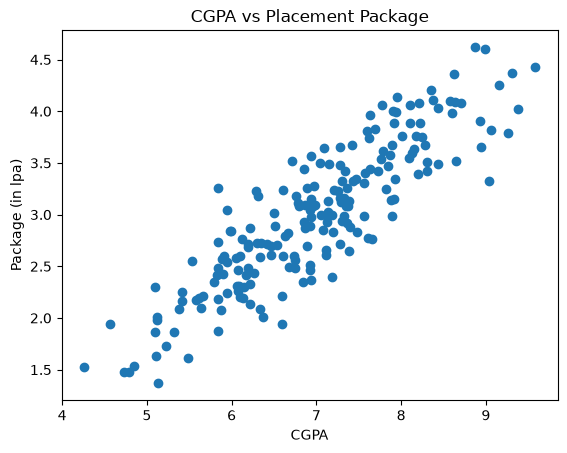

In [ ]:
# Load dataset
df = pd.read_csv('docs/Lecture-037-placement.csv')

# Visualize the relationship
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')
plt.title('CGPA vs Placement Package')
plt.show()

### **2. Train-Test Split & Model Training**

Separate the independent variable (`cgpa`) and dependent variable (`package`), split the data, and fit a simple linear regression model.

In [4]:
X = df[['cgpa']].copy()
y = df['package'].copy()

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions
y_pred = lr.predict(X_test)

### **3. Core Metrics: MAE, MSE, RMSE, and $R^2$ Score**

Calculate the fundamental regression error metrics to evaluate the model's accuracy.

In [5]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE:  0.2885
MSE:  0.1213
RMSE: 0.3483
R2 Score: 0.7807


### **4. Adjusted $R^2$ Score Calculation**

Adjusted $R^2$ penalizes the addition of independent variables that do not add predictive value to the model. It is calculated dynamically based on the shape of the test set.

In [6]:
n = X_test.shape[0]  # Number of observations
k = X_test.shape[1]  # Number of independent variables

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - 1 - k))
print(f"Adjusted R2 Score: {adj_r2:.4f}")

Adjusted R2 Score: 0.7750


### **5. Experiment 1: Adding a Random (Useless) Feature**

Introduce a completely random feature to observe how $R^2$ and Adjusted $R^2$ react. Standard $R^2$ may falsely improve or stay the same, but Adjusted $R^2$ will accurately drop.

In [7]:
# Create dataset with a useless random feature
df_random = df.copy()
df_random['random_feature'] = np.random.random(len(df_random))
X_rand = df_random[['cgpa', 'random_feature']]

# Split, Train, Predict
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_rand, y, test_size=0.2, random_state=2)
lr_rand = LinearRegression()
lr_rand.fit(X_train_rand, y_train_rand)
y_pred_rand = lr_rand.predict(X_test_rand)

# Calculate Metrics
r2_rand = r2_score(y_test_rand, y_pred_rand)
n_rand = X_test_rand.shape[0]
k_rand = X_test_rand.shape[1]
adj_r2_rand = 1 - ((1 - r2_rand) * (n_rand - 1) / (n_rand - 1 - k_rand))

print(f"R2 Score (with random feature): {r2_rand:.4f}")
print(f"Adjusted R2 (with random feature): {adj_r2_rand:.4f}")

R2 Score (with random feature): 0.7806
Adjusted R2 (with random feature): 0.7687


### **6. Experiment 2: Adding a Relevant Feature**

Introduce a feature (`iq`) that inherently correlates with the target variable to see both $R^2$ and Adjusted $R^2$ rise together.

In [8]:
# Create dataset with a relevant feature
df_relevant = df.copy()
df_relevant['iq'] = df_relevant['package'] + (np.random.randint(-12, 12, len(df_relevant)) / 10)
X_rel = df_relevant[['cgpa', 'iq']]

# Split, Train, Predict
X_train_rel, X_test_rel, y_train_rel, y_test_rel = train_test_split(X_rel, y, test_size=0.2, random_state=2)
lr_rel = LinearRegression()
lr_rel.fit(X_train_rel, y_train_rel)
y_pred_rel = lr_rel.predict(X_test_rel)

# Calculate Metrics
r2_rel = r2_score(y_test_rel, y_pred_rel)
n_rel = X_test_rel.shape[0]
k_rel = X_test_rel.shape[1]
adj_r2_rel = 1 - ((1 - r2_rel) * (n_rel - 1) / (n_rel - 1 - k_rel))

print(f"R2 Score (with relevant feature): {r2_rel:.4f}")
print(f"Adjusted R2 (with relevant feature): {adj_r2_rel:.4f}")

R2 Score (with relevant feature): 0.8419
Adjusted R2 (with relevant feature): 0.8333


## **7. Key Revision Notes**

- **Mean Absolute Error (MAE):** The average absolute distance between predicted and actual values. Robust to outliers.
- **Mean Squared Error (MSE):** The average of squared differences. Penalizes larger errors heavily but changes the original unit scale.
- **Root Mean Squared Error (RMSE):** The square root of MSE. Brings the error metric back to the original unit scale, making it highly interpretable while retaining the penalty for large errors.
- **$R^2$ Score (Coefficient of Determination):** Explains the proportion of variance in the dependent variable predictable from the independent variable(s). Ranges from $0$ to $1$ (higher is better).
- **Adjusted $R^2$:** Standard $R^2$ tends to increase even if a completely useless feature is added. Adjusted $R^2$ corrects this by adjusting for the number of predictors ($k$). It increases only if the new term improves the model more than expected by chance.